Decision Tree Model Trained Successfully

New Student Prediction:
Result = PASS


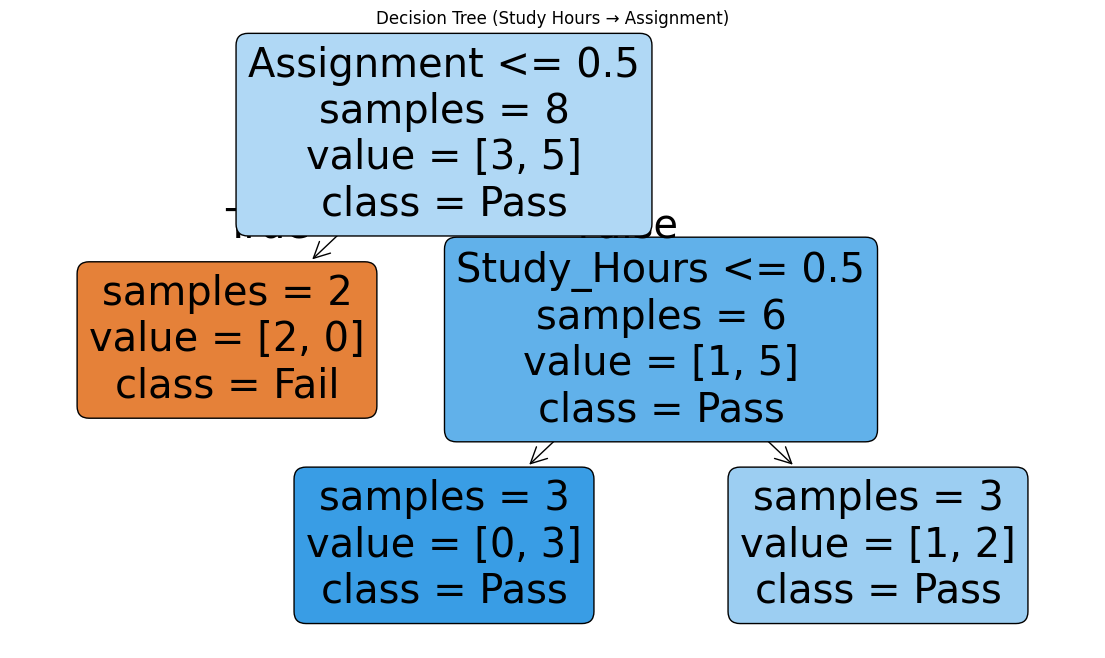

In [ ]:
# Decision Tree using matplotlib (WITHOUT entropy display)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------------
# Step 1: Create Dataset
# --------------------------------------------------
data = {
    'Study_Hours': ['High','High','Medium','Low','Low','Medium','Medium','High'],
    'Attendance': ['Good','Average','Good','Poor','Average','Average','Poor','Good'],
    'Assignment': ['Yes','Yes','Yes','No','Yes','Yes','No','Yes'],
    'Test_Score': ['High','Low','High','Low','Low','Low','Low','Low'],
    'Result': ['Pass','Pass','Pass','Fail','Fail','Pass','Fail','Pass']
}

df = pd.DataFrame(data)

# --------------------------------------------------
# Step 2: Label Encoding
# --------------------------------------------------
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# --------------------------------------------------
# Step 3: Split Features and Target
# Order kept to favor Study_Hours → Assignment
# --------------------------------------------------
X = df[['Study_Hours', 'Assignment', 'Attendance', 'Test_Score']]
y = df['Result']

# --------------------------------------------------
# Step 4: Train Decision Tree (Entropy)
# max_depth=2 encourages 2-level tree
# --------------------------------------------------
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=2,
    random_state=0
)
model.fit(X, y)

print("Decision Tree Model Trained Successfully")

# --------------------------------------------------
# Step 5: Classify New Sample
# Study Hours = Medium, Assignment = Yes,
# Attendance = Good, Test Score = Low
# --------------------------------------------------
new_sample = pd.DataFrame({
    'Study_Hours': [2],   # Medium
    'Assignment': [1],    # Yes
    'Attendance': [1],    # Good
    'Test_Score': [1]     # Low
})

prediction = model.predict(new_sample)

print("\nNew Student Prediction:")
print("Result =", "PASS" if prediction[0] == 1 else "FAIL")

# --------------------------------------------------
# Step 6: Plot Decision Tree
# --------------------------------------------------
plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    impurity=False
)

plt.title("Decision Tree (Study Hours → Assignment)")
plt.show()
